In [2]:
import numpy as np
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
plt.rcParams['svg.fonttype'] = 'none'

from os import path
import textwrap

dirname = '/Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Mesa et al/Lineage models/Annotability results/results_1405'

def label_point(x, y, val, ax=None):
    if ax == None:
        ax = plt.gca()
    a = pd.DataFrame({'x': x, 'y': y, 'val': val})
    for i, point in a.iterrows():
        ax.text(point['x']+.02, point['y'], str(point['val']))


# 1. Pure delays with relative features

In [6]:
ALL_features_correlations_ALL_DELAYS = pd.read_csv(path.join(dirname,'0104_not_aligned_results_with_relative_features/ALL_features_correlations_ALL_DELAYS.csv'),index_col=0)
# feature_correlation_heatmap = pd.read_csv(path.join(dirname,'not_aligned/feature_correlation_heatmap (2).csv'),index_col=0)
# top_correlated_features_ALL_DELAYS = pd.read_csv(path.join(dirname,'not_aligned/top_correlated_features_ALL_DELAYS (9).csv'),index_col=0)


,Fate,Feature,Confidence_Correlation,Confidence_Pvalue,Variability_Correlation,Variability_Pvalue,Conf_Significant,Var_Significant
Delay_hours,,,,,,,,
24,Basal,shcoeff_PC5,0.613331,0.000000e+00,-0.563728,0.000000e+00,True,True
24,Basal,Relative Basal area,0.606729,0.000000e+00,-0.483620,0.000000e+00,True,True
24,Basal,Basal area,0.569956,0.000000e+00,-0.467328,1.418400e-304,True,True
24,Basal,Cell volume exponential growth rate,0.467953,1.708925e-305,-0.386154,2.480562e-200,True,True
24,Basal,Nuclear volume exponential growth rate,0.419052,3.714325e-239,-0.350591,4.282061e-163,True,True
...,...,...,...,...,...,...,...,...
72,Suprabasal,Cell volume exponential growth rate,-0.242060,1.160467e-02,0.244949,1.061853e-02,True,True
72,Suprabasal,Cell volume G1 only exponential growth rate,-0.250871,8.823752e-03,0.292172,2.153125e-03,True,True
72,Suprabasal,Gaussian curvature 2um,-0.254328,7.904563e-03,0.269437,4.804818e-03,True,True


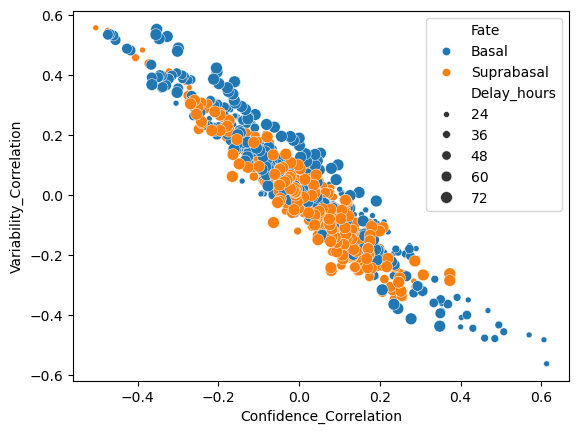

In [7]:
# df = ALL_features_correlations_ALL_DELAYS[ALL_features_correlations_ALL_DELAYS['Var_Significant'] & \
#                                         ALL_features_correlations_ALL_DELAYS['Conf_Significant'] &
#                                         (ALL_features_correlations_ALL_DELAYS['Variability_Correlation'] > 0)]
# df = ALL_features_correlations_ALL_DELAYS.reset_index().set_index('Fate').loc['Basal']
# sb.lineplot(df,x='Delay_hours',y='Confidence_Correlation',hue='Feature')

sb.scatterplot(ALL_features_correlations_ALL_DELAYS,x='Confidence_Correlation',y='Variability_Correlation',size='Delay_hours',hue='Fate')
ALL_features_correlations_ALL_DELAYS


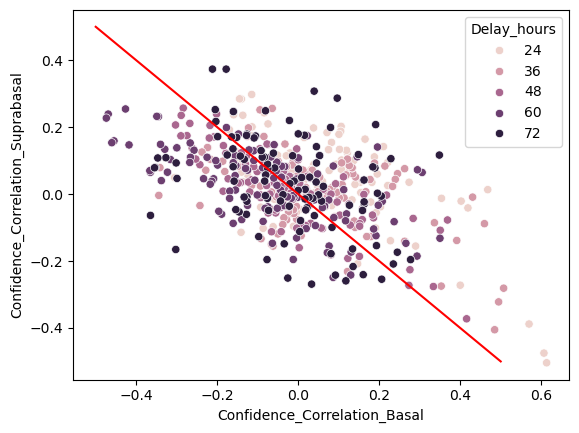

In [8]:
x = ALL_features_correlations_ALL_DELAYS.reset_index().set_index('Fate').loc['Basal'].set_index(['Feature','Delay_hours'])
y = ALL_features_correlations_ALL_DELAYS.reset_index().set_index('Fate').loc['Suprabasal'].set_index(['Feature','Delay_hours'])

df = pd.merge(x,y,left_index=True,right_index=True,suffixes=['_Basal','_Suprabasal'])
sb.scatterplot(df.reset_index(),x='Confidence_Correlation_Basal',y='Confidence_Correlation_Suprabasal',
               hue='Delay_hours')

plt.plot([-.5,.5],[.5,-.5],color='r')

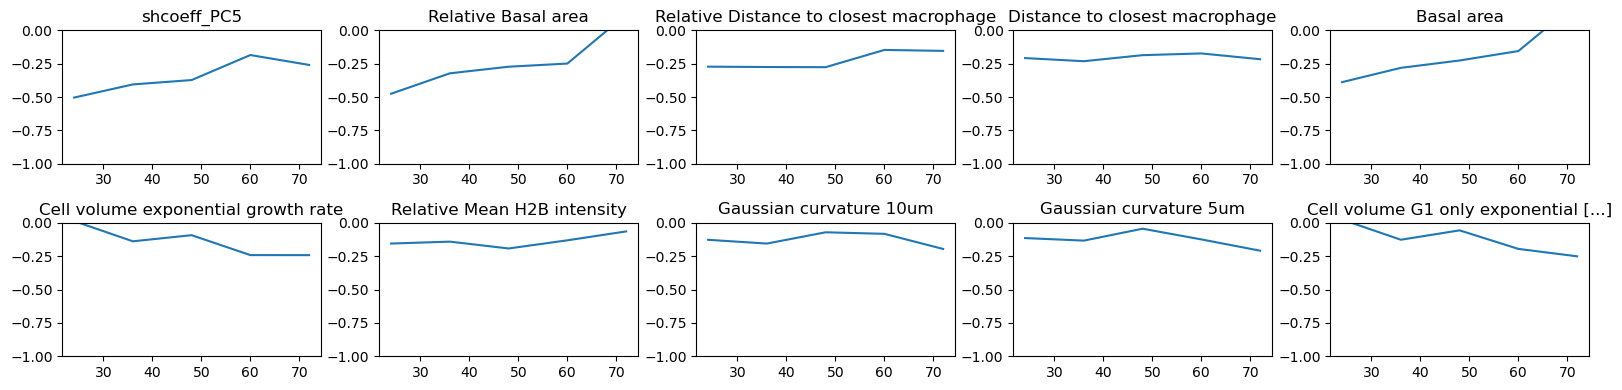

In [105]:

import textwrap

ALL_features_correlations_ALL_DELAYS = ALL_features_correlations_ALL_DELAYS.reset_index().set_index(['Feature','Delay_hours'])
ALL_features_correlations_ALL_DELAYS_basal = ALL_features_correlations_ALL_DELAYS[ALL_features_correlations_ALL_DELAYS['Fate'] == 'Basal']
ALL_features_correlations_ALL_DELAYS_suprabasal = ALL_features_correlations_ALL_DELAYS[ALL_features_correlations_ALL_DELAYS['Fate'] == 'Suprabasal']

basal_confR = ALL_features_correlations_ALL_DELAYS_basal.reset_index().groupby('Feature')['Confidence_Correlation'].mean()
supra_confR = ALL_features_correlations_ALL_DELAYS_suprabasal.reset_index().groupby('Feature')['Confidence_Correlation'].mean()

x = [24,36,48,60,72]
fig = plt.figure(figsize=[16,4])
Ncol = 10

for i in range(Ncol):
    
    plt.subplot(2,5,i+1)
    f = supra_confR.sort_values(ascending=True).head(10).index.values[i]
    plt.plot(ALL_features_correlations_ALL_DELAYS_suprabasal.loc[f,:]['Confidence_Correlation'])
    plt.ylim([-1,0])
    plt.title(textwrap.shorten(f,40))
    
fig.tight_layout()  
# fig.savefig('/Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Mesa et al/Lineage models/Annotability results/not_aligned/top10_confidence_correlated.svg')



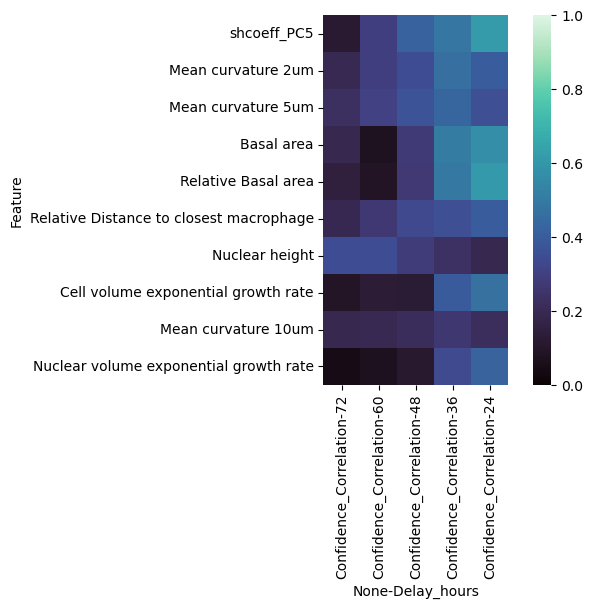

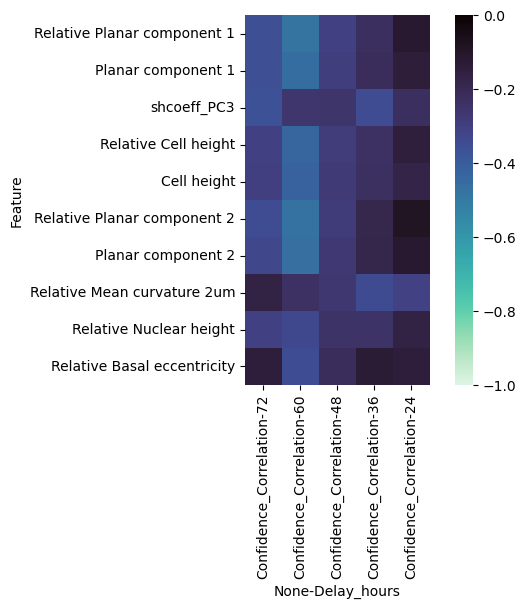

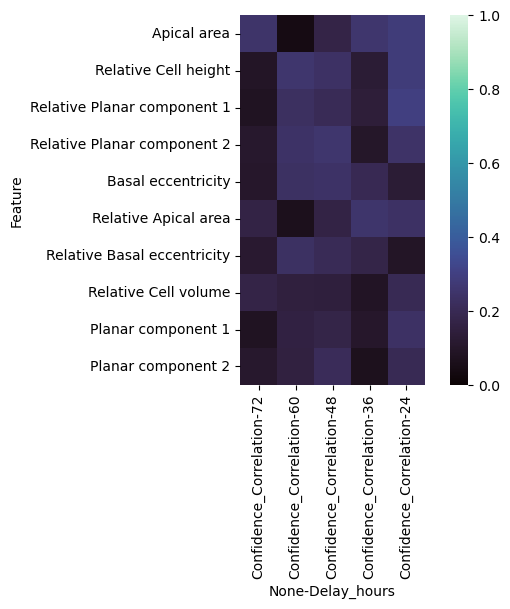

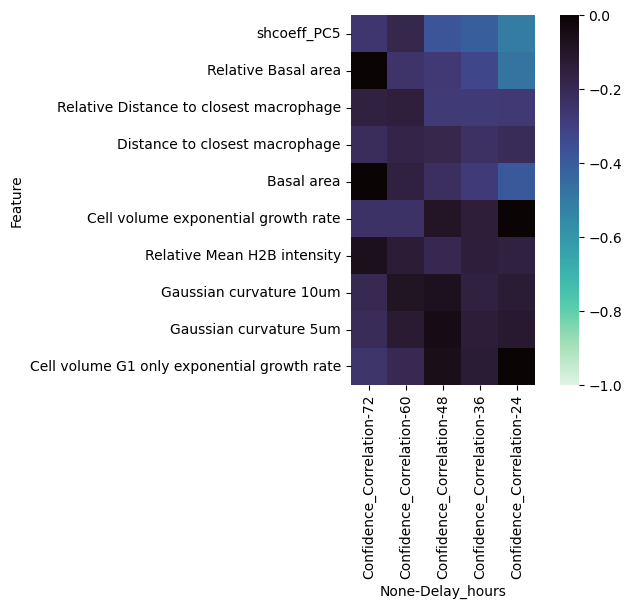

In [106]:
_df = ALL_features_correlations_ALL_DELAYS_basal['Confidence_Correlation'].reset_index(level=1).pivot(columns='Delay_hours').iloc[::,::-1]
sb.heatmap(_df.loc[basal_confR.sort_values(ascending=False).head(10).index.values,:],vmin=0,vmax=1, cmap='mako')
plt.gca().set_aspect('equal')
plt.savefig(path.join(dirname,'pure_delays_basal_corr_conf.svg'))

plt.figure()
_df = ALL_features_correlations_ALL_DELAYS_basal['Confidence_Correlation'].reset_index(level=1).pivot(columns='Delay_hours').iloc[::,::-1]
sb.heatmap(_df.loc[basal_confR.sort_values(ascending=True).head(10).index.values,:],vmin=-1,vmax=0, cmap='mako_r')
plt.gca().set_aspect('equal')
plt.savefig(path.join(dirname,'pure_delays_basal_anticorr_conf.svg'))

plt.figure()
_df = ALL_features_correlations_ALL_DELAYS_suprabasal['Confidence_Correlation'].reset_index(level=1).pivot(columns='Delay_hours').iloc[::,::-1]
sb.heatmap(_df.loc[supra_confR.sort_values(ascending=False).head(10).index.values,:],vmin=0,vmax=1, cmap='mako')
plt.gca().set_aspect('equal')
plt.savefig(path.join(dirname,'pure_delays_supra_corr_conf.svg'))

plt.figure()
_df = ALL_features_correlations_ALL_DELAYS_suprabasal['Confidence_Correlation'].reset_index(level=1).pivot(columns='Delay_hours').iloc[::,::-1]
sb.heatmap(_df.loc[supra_confR.sort_values(ascending=True).head(10).index.values,:],vmin=-1,vmax=0, cmap='mako_r')
plt.gca().set_aspect('equal')
plt.savefig(path.join(dirname,'pure_delays_supra_anticorr_conf.svg'))

# 2. Cell cycle aligned

In [5]:
correlations = pd.read_csv(path.join(dirname,'correlation_results/correlations_ALL_TIMEPOINTS_full.csv'),index_col=0)

top_correlations = pd.read_csv(path.join(dirname,'correlation_results/top_correlations_ALL_TIMEPOINTS.csv'),index_col=0)



# print(correlations['Feature'].unique())
# # correlations

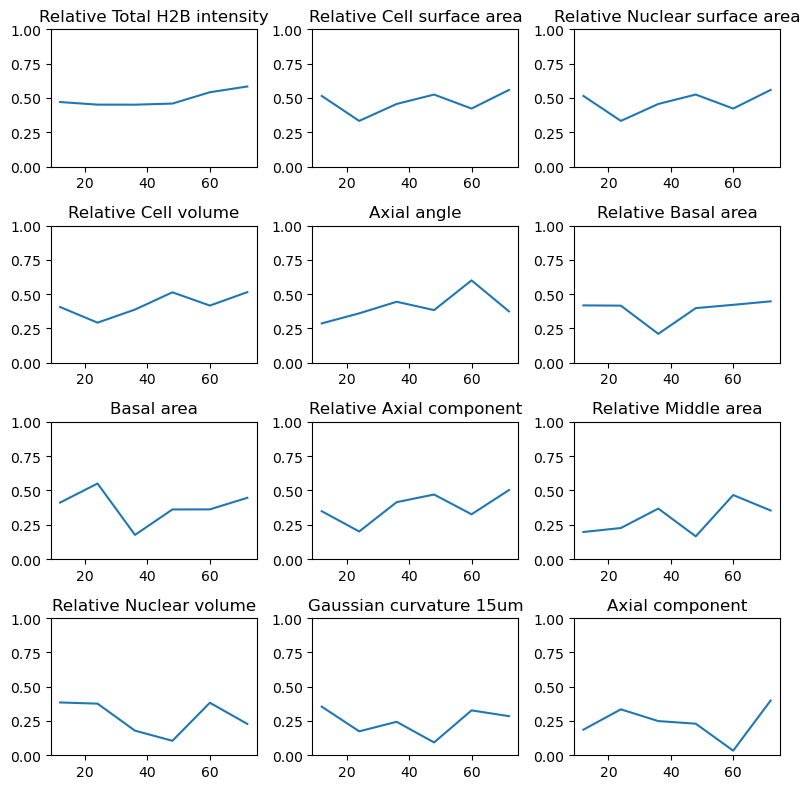

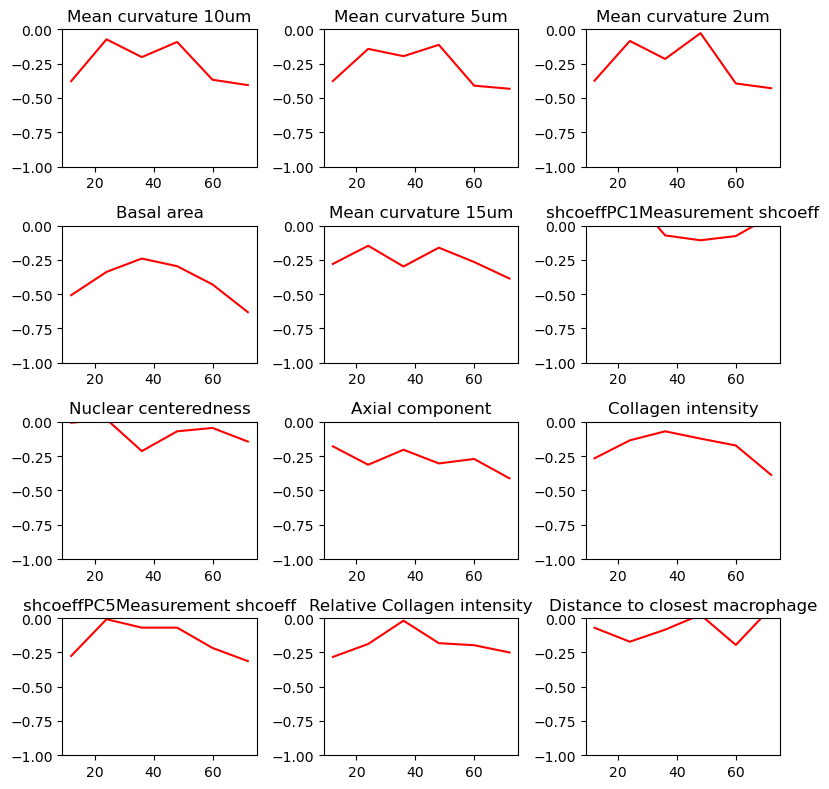

In [6]:
basal_correlations = correlations.reset_index().set_index('Fate').loc['Both Basal (0)'].set_index(['Feature','Delay_hours'])
supra_correlations = correlations.reset_index().set_index('Fate').loc['Asymmetric or Suprabasal (1+2)'].set_index(['Feature','Delay_hours'])

basal_confR = basal_correlations.reset_index().groupby('Feature')['Confidence_Correlation'].mean()
supra_confR = correlations.reset_index().groupby('Feature')['Confidence_Correlation'].mean()

fig = plt.figure(figsize=(8,8))
for i in range(12):
    plt.subplot(4,3,i+1)
    f = basal_confR.sort_values(ascending=False).index.values[i]
    plt.plot(basal_correlations.loc[f,:]['Confidence_Correlation'])
    plt.ylim([0,1])
    plt.title(textwrap.shorten(''.join(f.split('_')[0:-1]),50))
plt.tight_layout()

fig = plt.figure(figsize=(8,8))
for i in range(12):
    plt.subplot(4,3,i+1)
    f = supra_confR.sort_values(ascending=True).index.values[i]
    plt.plot(supra_correlations.loc[f,:]['Confidence_Correlation'],color='r')
    plt.ylim([-1,0])
    plt.title(textwrap.shorten(''.join(f.split('_')[0:-1]),50))
plt.tight_layout()


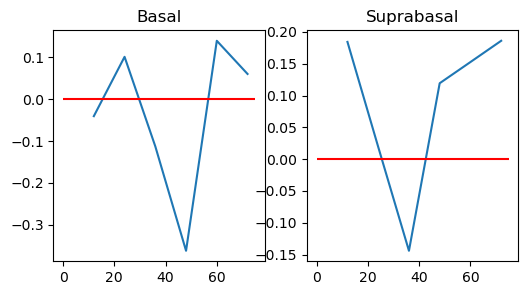

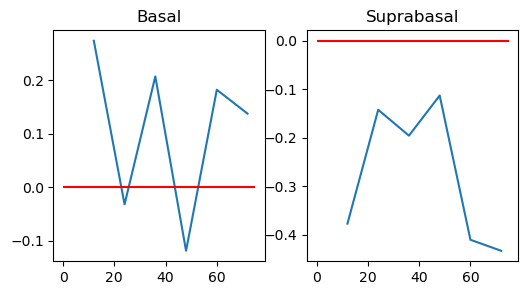

In [7]:

fig = plt.figure(figsize=(6,3))

y = 'Collagen coherence_Measurement collagen'

plt.subplot(1,2,1)
plt.plot(basal_correlations.loc[y,:]['Confidence_Correlation'])
plt.title('Basal')
plt.hlines(xmin=0,xmax=75,y=0,color='r')
plt.subplot(1,2,2)
plt.plot(supra_correlations.loc[y,:]['Confidence_Correlation'])
plt.title('Suprabasal')
plt.hlines(xmin=0,xmax=75,y=0,color='r')



fig = plt.figure(figsize=(6,3))

y = 'Mean curvature 5um_Measurement tissue geometry'

plt.subplot(1,2,1)
plt.plot(basal_correlations.loc[y,:]['Confidence_Correlation'])
plt.title('Basal')
plt.hlines(xmin=0,xmax=75,y=0,color='r')
plt.subplot(1,2,2)
plt.plot(supra_correlations.loc[y,:]['Confidence_Correlation'])
plt.title('Suprabasal')
plt.hlines(xmin=0,xmax=75,y=0,color='r')


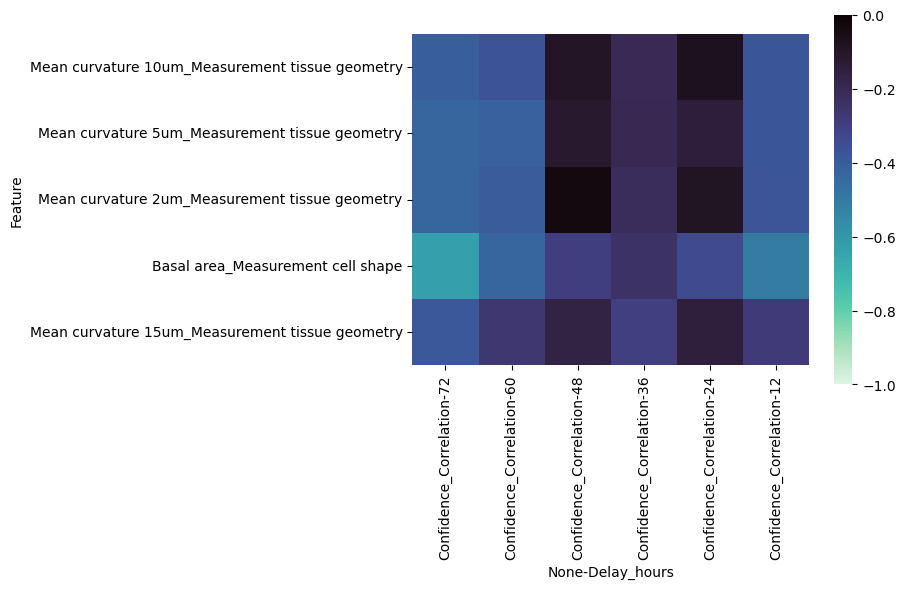

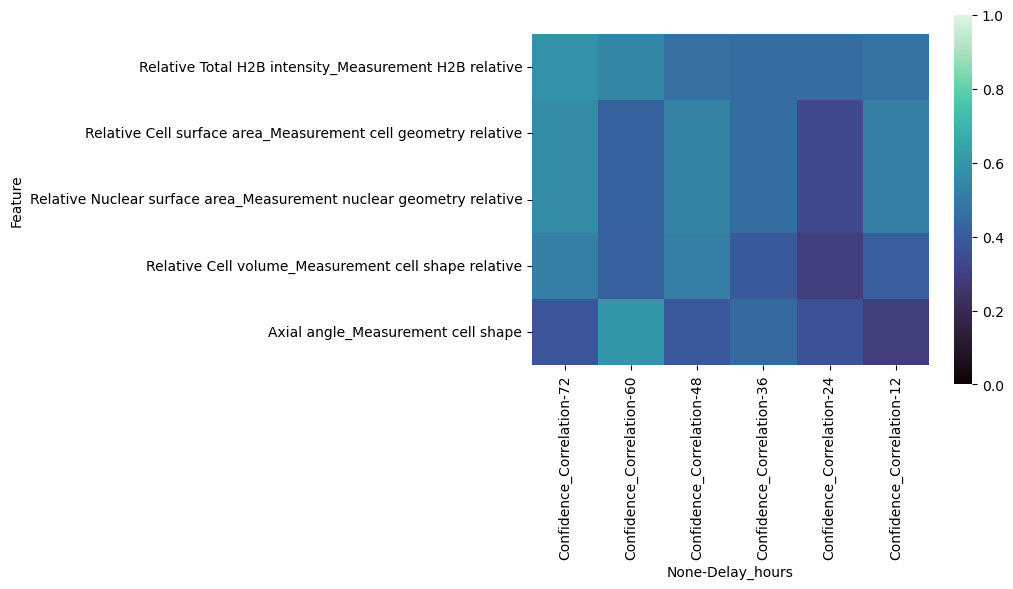

In [8]:
_df = supra_correlations['Confidence_Correlation'].reset_index(level=1).pivot(columns='Delay_hours').iloc[::,::-1]
sb.heatmap(_df.loc[supra_confR.sort_values(ascending=True).head(5).index.values,:],vmin=-1,vmax=0, cmap='mako_r',)
plt.gca().set_aspect('equal')
# plt.savefig(path.join(dirname,'aligned_delays_supra_anticorr_conf.svg'))

plt.figure()
_df = basal_correlations['Confidence_Correlation'].reset_index(level=1).pivot(columns='Delay_hours').iloc[::,::-1]
sb.heatmap(_df.loc[basal_confR.sort_values(ascending=False).head(5).index.values,:],vmin=0,vmax=1, cmap='mako')
plt.gca().set_aspect('equal')
# plt.savefig(path.join(dirname,'aligned_delays_basal_corr_conf.svg'))


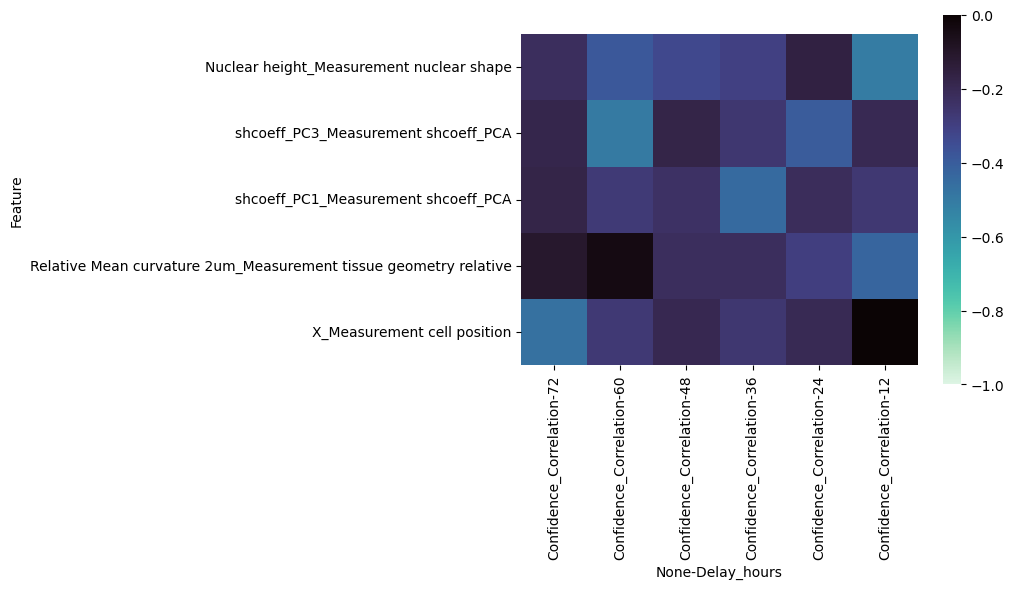

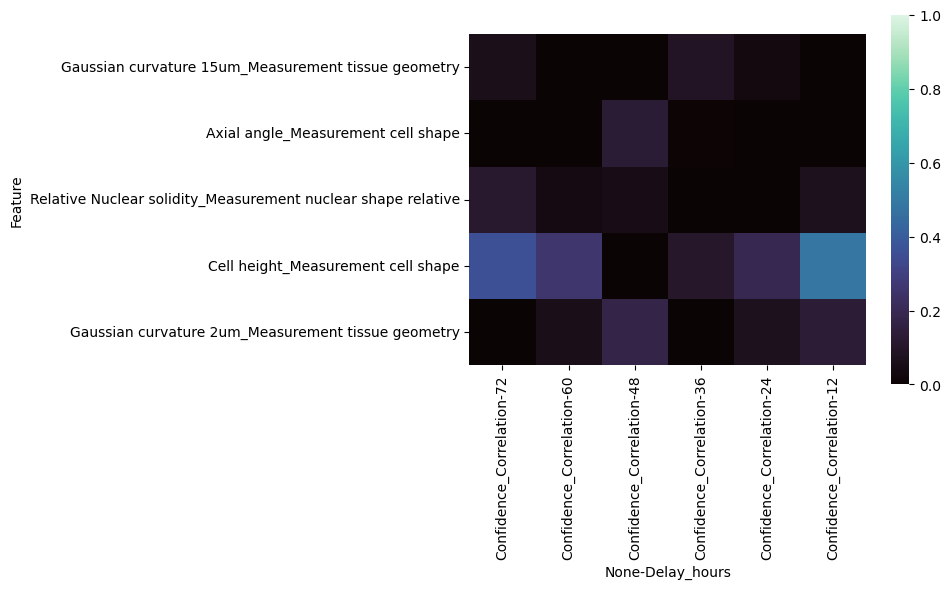

In [9]:

_df = basal_correlations['Confidence_Correlation'].reset_index(level=1).pivot(columns='Delay_hours').iloc[::,::-1]
sb.heatmap(_df.loc[basal_confR.sort_values(ascending=True).head(5).index.values,:],vmin=-1,vmax=0, cmap='mako_r',)
plt.gca().set_aspect('equal')
# plt.savefig(path.join(dirname,'aligned_delays_basal_anticorr_conf.svg'))

plt.figure()
_df = supra_correlations['Confidence_Correlation'].reset_index(level=1).pivot(columns='Delay_hours').iloc[::,::-1]
sb.heatmap(_df.loc[supra_confR.sort_values(ascending=False).head(5).index.values,:],vmin=0,vmax=1, cmap='mako')
plt.gca().set_aspect('equal')
# plt.savefig(path.join(dirname,'aligned_delays_supra_corr_conf.svg'))


<Axes: title={'center': 'Top 5 renewal anti-predictors'}, xlabel='Feature'>

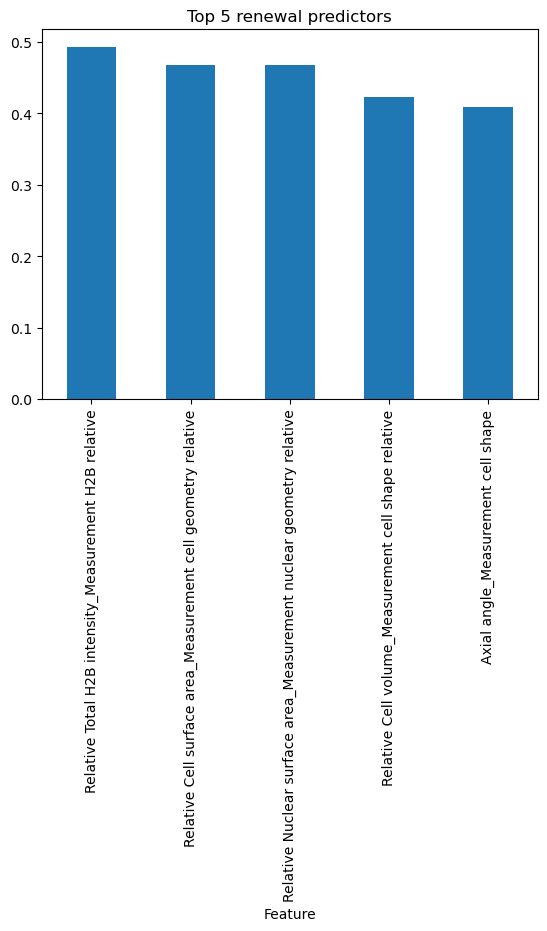

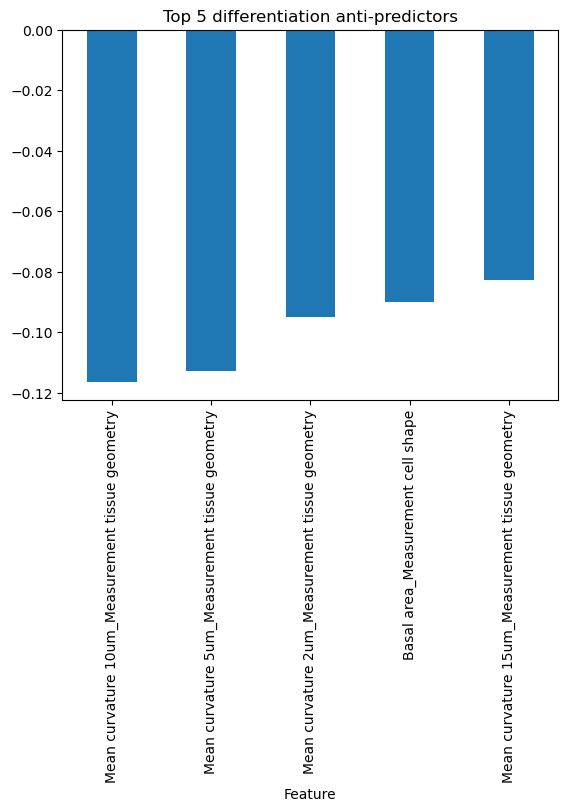

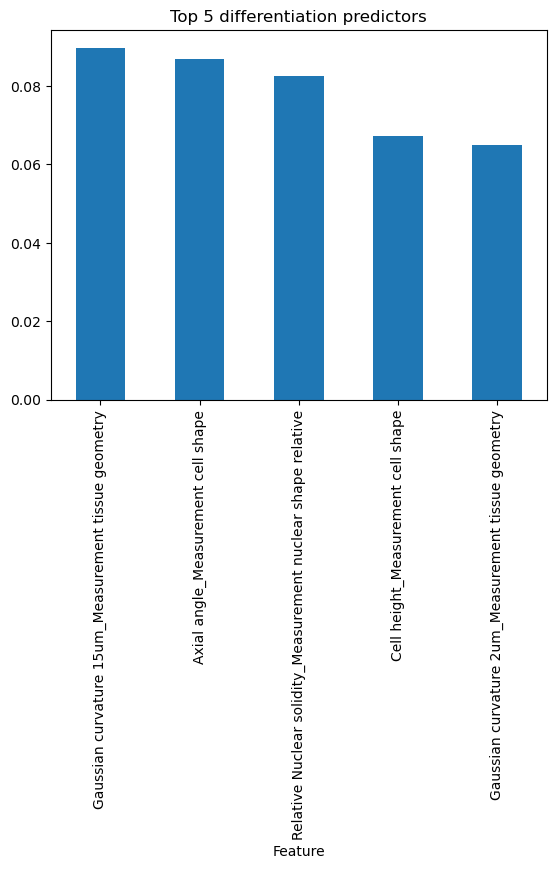

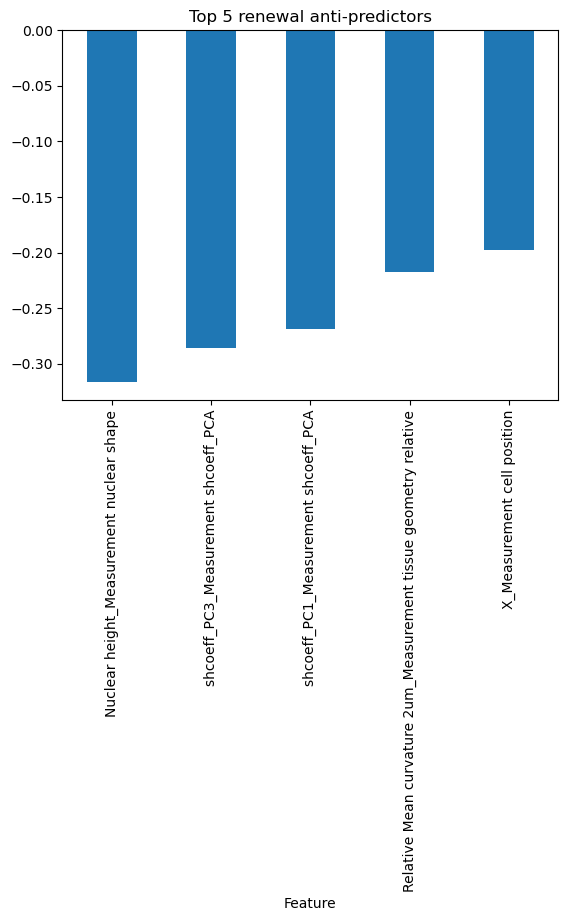

In [10]:

plt.title('Top 5 renewal predictors')
basal_confR.sort_values(ascending=False).head(5).plot.bar()
# plt.savefig(path.join(dirname,'top5_basal_confcorr.svg'))

plt.figure()
plt.title('Top 5 differentiation anti-predictors')
supra_confR.sort_values(ascending=True).head(5).plot.bar()
# plt.savefig(path.join(dirname,'top5_supra_anticonfcorr.svg'))

plt.figure()
plt.title('Top 5 differentiation predictors')
supra_confR.sort_values(ascending=False).head(5).plot.bar()
# plt.savefig(path.join(dirname,'top5_supra_confcorr.svg'))

plt.figure()
plt.title('Top 5 renewal anti-predictors')
basal_confR.sort_values(ascending=True).head(5).plot.bar()
# plt.savefig(path.join(dirname,'top5_basal_anticonfcorr.svg'))


(-1.0, 0.0)

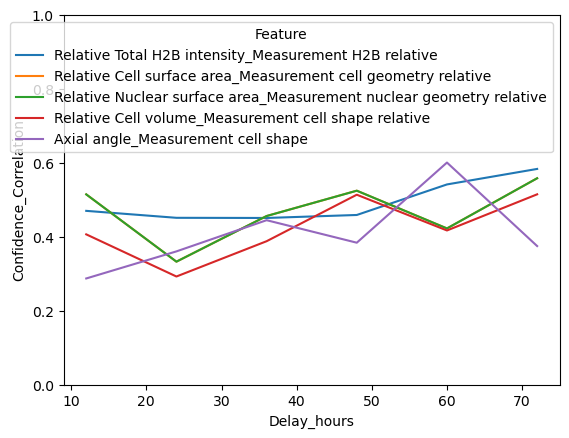

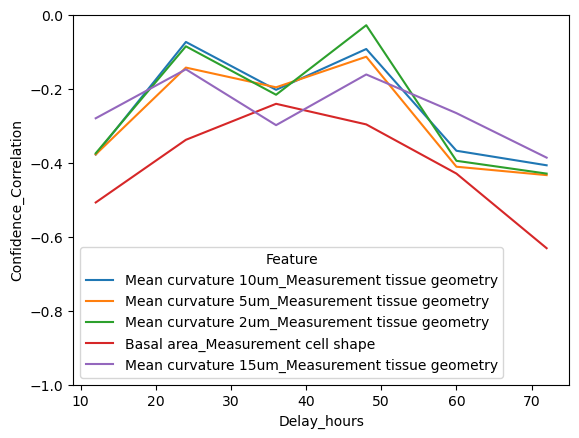

In [11]:
# basal_correlations.loc[basal_confR.sort_values(ascending=False).head(5).index].T.plot()
sb.lineplot(basal_correlations.loc[basal_confR.sort_values(ascending=False).head(5).index]['Confidence_Correlation'].reset_index(),
            x='Delay_hours',y='Confidence_Correlation',hue='Feature')
plt.ylim([0,1])
# plt.savefig(path.join(dirname,'top_basal_corrconf_line.svg'))

plt.figure()
sb.lineplot(supra_correlations.loc[supra_confR.sort_values(ascending=True).head(5).index]['Confidence_Correlation'].reset_index(),
            x='Delay_hours',y='Confidence_Correlation',hue='Feature')
plt.ylim([-1,0])
# plt.savefig(path.join(dirname,'top_supra_anticorrconf_line.svg'))

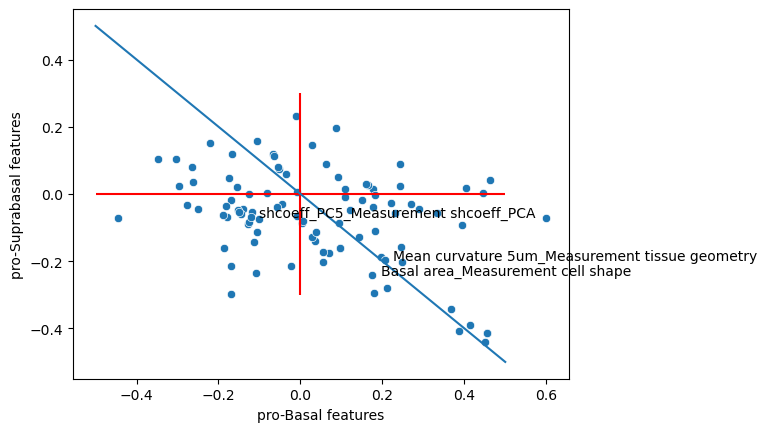

In [12]:
_df = pd.merge(basal_correlations.swaplevel(axis=0).loc[36],
               supra_correlations.swaplevel(axis=0).loc[36],
               left_index=True,right_index=True,suffixes=['_basal','_suprabasal'])

x = 'Confidence_Correlation_basal'
y = 'Confidence_Correlation_suprabasal'
plt.close('all')
sb.scatterplot(_df,x=x,y=y)
plt.xlabel('pro-Basal features')
plt.ylabel('pro-Suprabasal features')
plt.vlines(0,ymin=-0.3,ymax=.3,color='r')
plt.hlines(0,xmin=-0.5,xmax=.5,color='r')


feature = _df.loc[[
      # 'Mean curvature 2um_Measurement tissue geometry',
      'Mean curvature 5um_Measurement tissue geometry',
      # 'Mean curvature 10um_Measurement tissue geometry'
            ]]
label_point(feature[x],feature[y],feature.index)

feature = _df.loc[['shcoeff_PC5_Measurement shcoeff_PCA',
                  'Basal area_Measurement cell shape']]
label_point(feature[x],feature[y],feature.index)

# feature = _df.loc[['Relative Nuclear surface area_Measurement nuclear geometry relative']]
# label_point(feature[x],feature[y],feature.index)

plt.plot([-.5,.5],[.5,-.5])


In [217]:
correlations['Fate'].unique()

array(['Asymmetric or Suprabasal (1+2)', 'Both Basal (0)', 'ALL'],
      dtype=object)

In [231]:
basal_correlations

,,Confidence_Correlation,Confidence_Pvalue,Variability_Correlation,Variability_Pvalue
Feature,Delay_hours,,,,
Nuclear volume_Measurement nuclear shape,12,-0.153636,0.363950,0.107048,0.528294
Nuclear solidity_Measurement nuclear shape,12,-0.027501,0.871643,0.023234,0.891432
Nuclear height_Measurement nuclear shape,12,0.486025,0.002290,-0.335824,0.042147
Cell volume_Measurement cell shape,12,-0.310574,0.061363,0.528450,0.000774
Axial component_Measurement cell shape,12,0.094832,0.576639,0.094595,0.577597
...,...,...,...,...,...
Mean distance to neighbors_Measurement cell position,72,0.246087,0.246395,-0.407826,0.047901
Median distance to neighbors_Measurement cell position,72,0.168696,0.430702,-0.375652,0.070454
Max distance to neighbors_Measurement cell position,72,0.240000,0.258646,-0.164348,0.442846


<Axes: xlabel='Delay_hours', ylabel='Feature'>

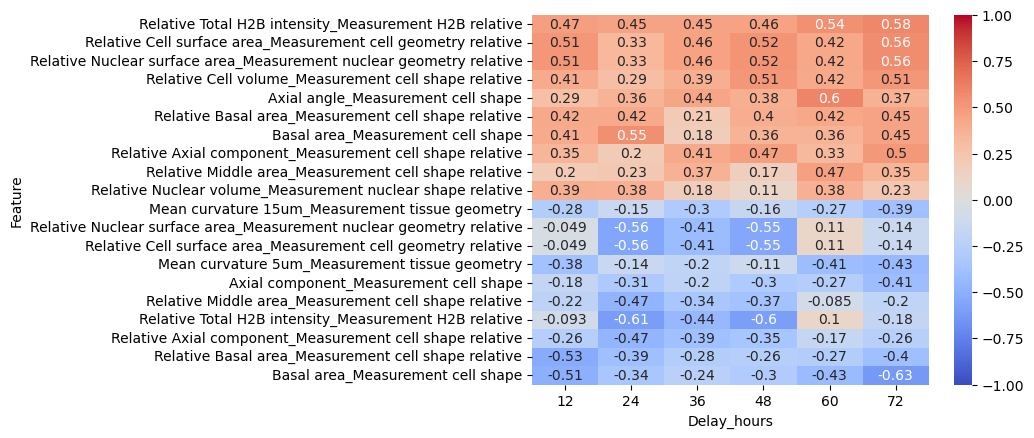

In [13]:

_df = basal_correlations.drop(columns=['Confidence_Pvalue','Variability_Correlation','Variability_Pvalue']).reset_index()
basal_corrMat = _df.pivot(index=['Feature'],columns='Delay_hours',values='Confidence_Correlation')
basal_positive = basal_corrMat.T.mean().sort_values(ascending=False)[basal_corrMat.T.mean().sort_values() > 0].index

_df = supra_correlations.drop(columns=['Confidence_Pvalue','Variability_Correlation','Variability_Pvalue']).reset_index()
supra_corrMat = _df.pivot(index=['Feature'],columns='Delay_hours',values='Confidence_Correlation')
supra_negative = supra_corrMat.T.mean().sort_values(ascending=False)[supra_corrMat.T.mean().sort_values() < 0].index

# basal_corrMat
basal_features = pd.concat([ basal_corrMat.loc[basal_positive[:10]],supra_corrMat.loc[supra_negative[-10:] ] ])
sb.heatmap(basal_features,cmap='coolwarm',vmax=1,vmin=-1, annot=True)
# plt.savefig(path.join(dirname,'basal_features_heatmap.svg'))

# _df = _df.drop(columns=['Confidence_Pvalue','Variability_Correlation','Variability_Pvalue'])

# sb.heatmap(_df,vmin=-1,vmax=1)


<Axes: xlabel='Delay_hours', ylabel='Feature'>

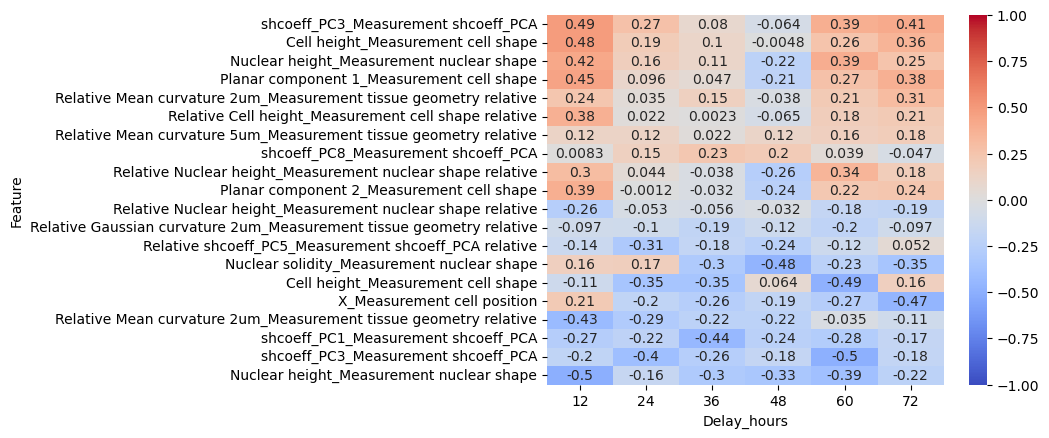

In [14]:
basal_negative = basal_corrMat.T.mean().sort_values(ascending=False)[basal_corrMat.T.mean().sort_values() < 0].index

supra_positive = supra_corrMat.T.mean().sort_values(ascending=False)[supra_corrMat.T.mean().sort_values() > 0].index

# basal_corrMat
basal_features = pd.concat([ supra_corrMat.loc[supra_positive[:10]],basal_corrMat.loc[basal_negative[-10:]] ])
sb.heatmap(basal_features,cmap='coolwarm',vmax=1,vmin=-1, annot=True)
# plt.savefig(path.join(dirname,'supra_features_heatmap.svg'))

# _df = _df.drop(columns=['Confidence_Pvalue','Variability_Correlation','Variability_Pvalue'])

# sb.heatmap(_df,vmin=-1,vmax=1)


In [29]:
basal_positive[:5]

Index(['Basal area_Measurement cell shape',
       'Nuclear height_Measurement nuclear shape',
       'Axial angle_Measurement cell shape',
       'Middle area_Measurement cell shape',
       'Axial component_Measurement cell shape'],
      dtype='object', name='Feature')

In [30]:

raw_scores_delayed = {delay:
                      pd.read_csv(path.join(dirname,f'0104aligned__results_without_relative_features/correlation_results/raw_scores_{delay}h.csv'),index_col=0)
                     for delay in [12,24,36,48,60,72]}

all_raws = []
for delay,df in raw_scores_delayed.items():
    df['Delay'] = delay
    all_raws.append(df.reset_index())
all_raws = pd.concat(all_raws,ignore_index=True)


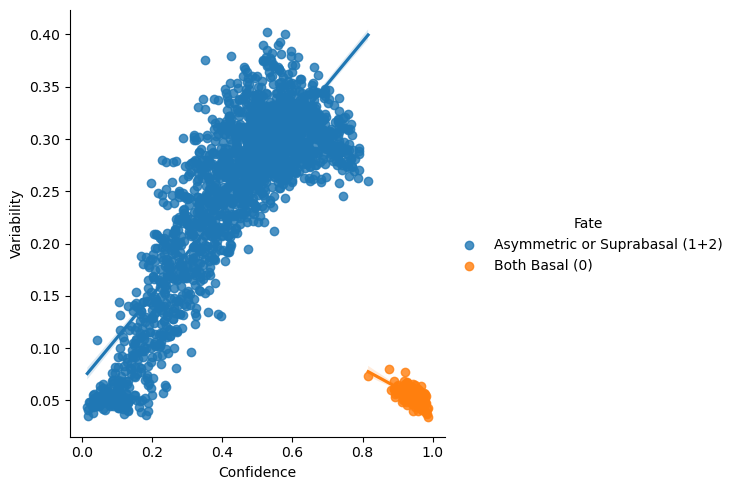

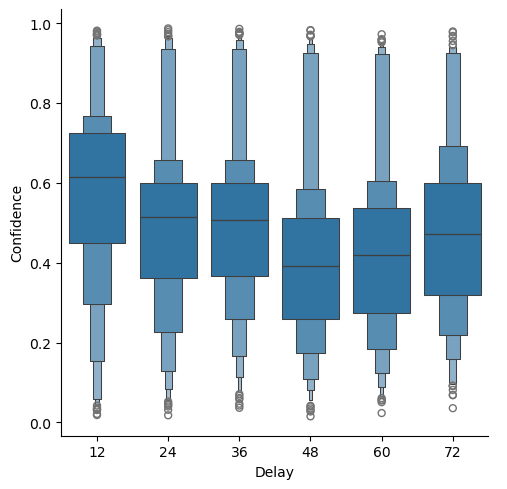

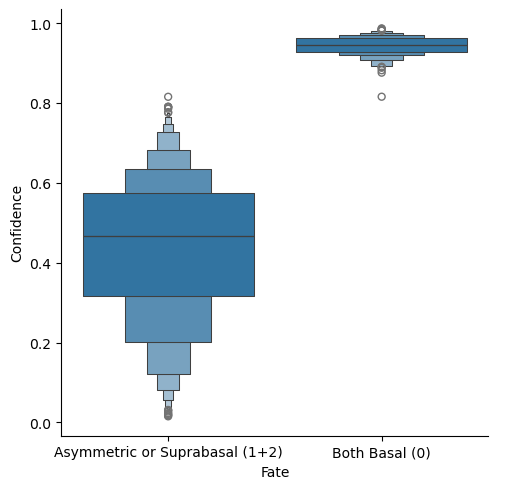

In [19]:
sb.lmplot(all_raws,hue='Fate',x='Confidence',y='Variability')
sb.catplot(all_raws,x='Delay',y='Confidence',kind='boxen')
sb.catplot(all_raws,x='Fate',y='Confidence',kind='boxen')

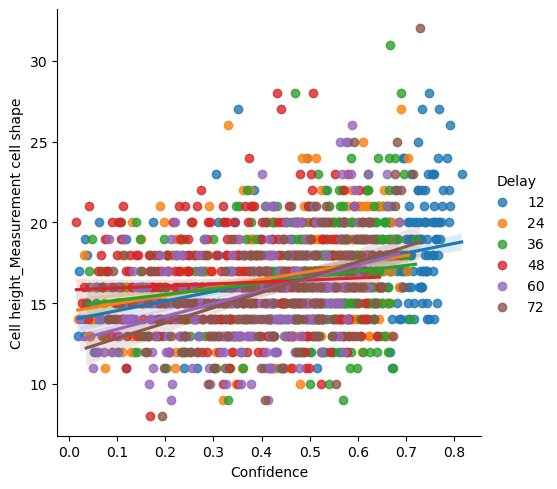

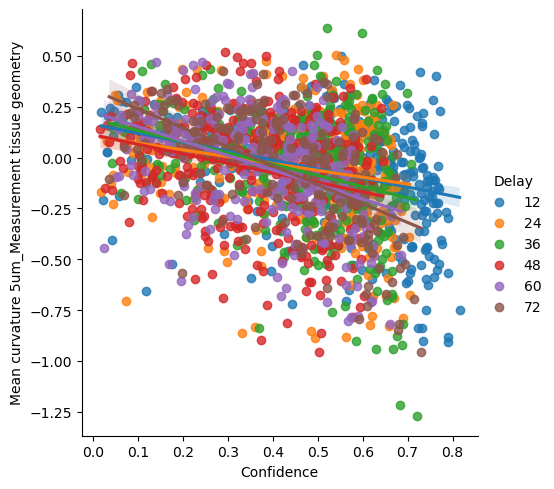

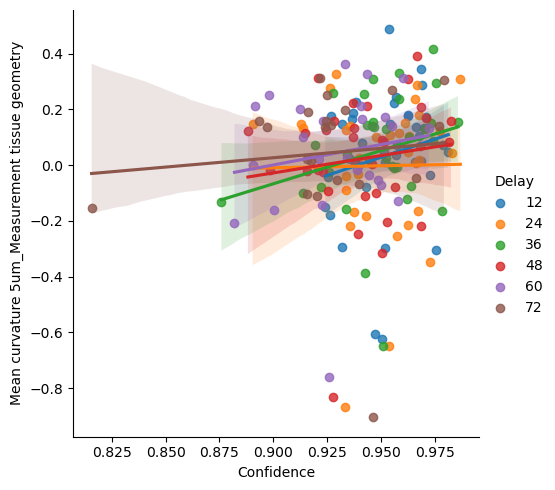

In [41]:
sb.lmplot(all_raws.set_index('Fate').loc['Asymmetric or Suprabasal (1+2)'],
          hue='Delay',x='Confidence',y='Cell height_Measurement cell shape')


sb.lmplot(all_raws.set_index('Fate').loc['Asymmetric or Suprabasal (1+2)'],
          hue='Delay',x='Confidence',y='Mean curvature 5um_Measurement tissue geometry')

sb.lmplot(all_raws.set_index('Fate').loc['Both Basal (0)'],
          hue='Delay',x='Confidence',y='Mean curvature 5um_Measurement tissue geometry')

# sb.catplot(all_raws,x='Delay',y='Confidence',kind='boxen')
# sb.catplot(all_raws,x='Fate',y='Confidence',kind='boxen')

In [44]:
#  Mean Confidence over time